<a href="https://colab.research.google.com/github/Bushra-3259/Financial-Fraud-Detection-ML-Project-/blob/main/Financial_Fraud_Detection_(ML_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import Libraries**

In [4]:
# Cell 1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#**Explore Data**

In [5]:
# Cell 2

df = pd.read_csv("/content/synthetic_fraud_dataset.csv")
print(df.head())
print(df.info())
print(df['is_fraud'].value_counts())

   transaction_id  user_id   amount transaction_type merchant_category  \
0               1      202  3185.04           Online            Travel   
1               2      535  2776.30               QR       Electronics   
2               3      960   459.56              ATM          Clothing   
3               4      370  3633.35               QR              Food   
4               5      206  2739.49           Online          Clothing   

  country  hour  device_risk_score  ip_risk_score  is_fraud  
0      UK    19           0.209554       0.270994         0  
1      DE     8           0.000000       0.079065         0  
2      UK    21           0.264641       0.640751         0  
3      DE    14           0.353649       0.308512         0  
4      UK     0           0.605898       0.422656         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             ------

#**Duplicates check**

In [6]:
# Cell 3

# 1. Physical Duplicate Check (Exact row matches)
total_dups = df.duplicated().sum()
print(f"Total Exact Duplicates: {total_dups}")

# 2. Logical Duplicate Check (Same user, amount, and hour)
# This finds people potentially "double-clicking" or system errors
logical_dups = df.duplicated(subset=['user_id', 'amount', 'hour']).sum()
print(f"Logical Duplicates (User/Amount/Hour): {logical_dups}")

# 3. Handling: Remove Duplicates
if total_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Action: Removed exact duplicates to prevent model bias.")
else:
    print("Action: No exact duplicates found. Data is clean.")

Total Exact Duplicates: 0
Logical Duplicates (User/Amount/Hour): 4
Action: No exact duplicates found. Data is clean.


#**Check fraud ratio**
The ratio shows that the dataset is imbalanced (5% fraud vs 95% legitimate). This tells me that I cannot rely on Accuracy alone to evaluate my model.
Because the fraud ratio is low, a high accuracy score might be misleading. I need to focus on metrics like Precision, Recall, and the F1-Score to ensure the model is actually catching the 5% of fraud cases.

In [7]:
# Cell 4

fraud_ratio = df['is_fraud'].mean()
print(f"Fraud Ratio: {fraud_ratio:.2%}")

Fraud Ratio: 21.02%


**Split Data**

In [8]:
# Cell 5

from sklearn.model_selection import train_test_split

X = df.drop(['is_fraud', 'transaction_id', 'user_id'], axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#**Preprocess and Pipeline the Data**
Organizing raw data by cleaning, transforming, feature encoding (Converting Text to Numbers), feature scaling (Normalization), Handling Class Imbalance, and Split Data to make it suitable for a machine learning model.

In [9]:
# Cell 6

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier

# 1. Custom transformer for combined risk
class RiskFeatureAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy['combined_risk'] = X_copy['device_risk_score'] * X_copy['ip_risk_score']
        return X_copy

# 2. Define features for the transformer
cat_cols = ['transaction_type', 'merchant_category', 'country']
num_cols = ['amount', 'hour', 'device_risk_score', 'ip_risk_score', 'combined_risk']

# 3. Handle specific columns safely using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# 4. Assemble the final unified Pipeline (100 estimators, max_depth=5 for full training)
fraud_model_pipeline = Pipeline([
    ('risk_adder', RiskFeatureAdder()),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))
])

# Train the pipeline entirely on RAW data
fraud_model_pipeline.fit(X_train, y_train)
print("Pipeline trained securely with 0% Data Leakage!")

Pipeline trained securely with 0% Data Leakage!


#**Train ML Models**


**Decision trees**

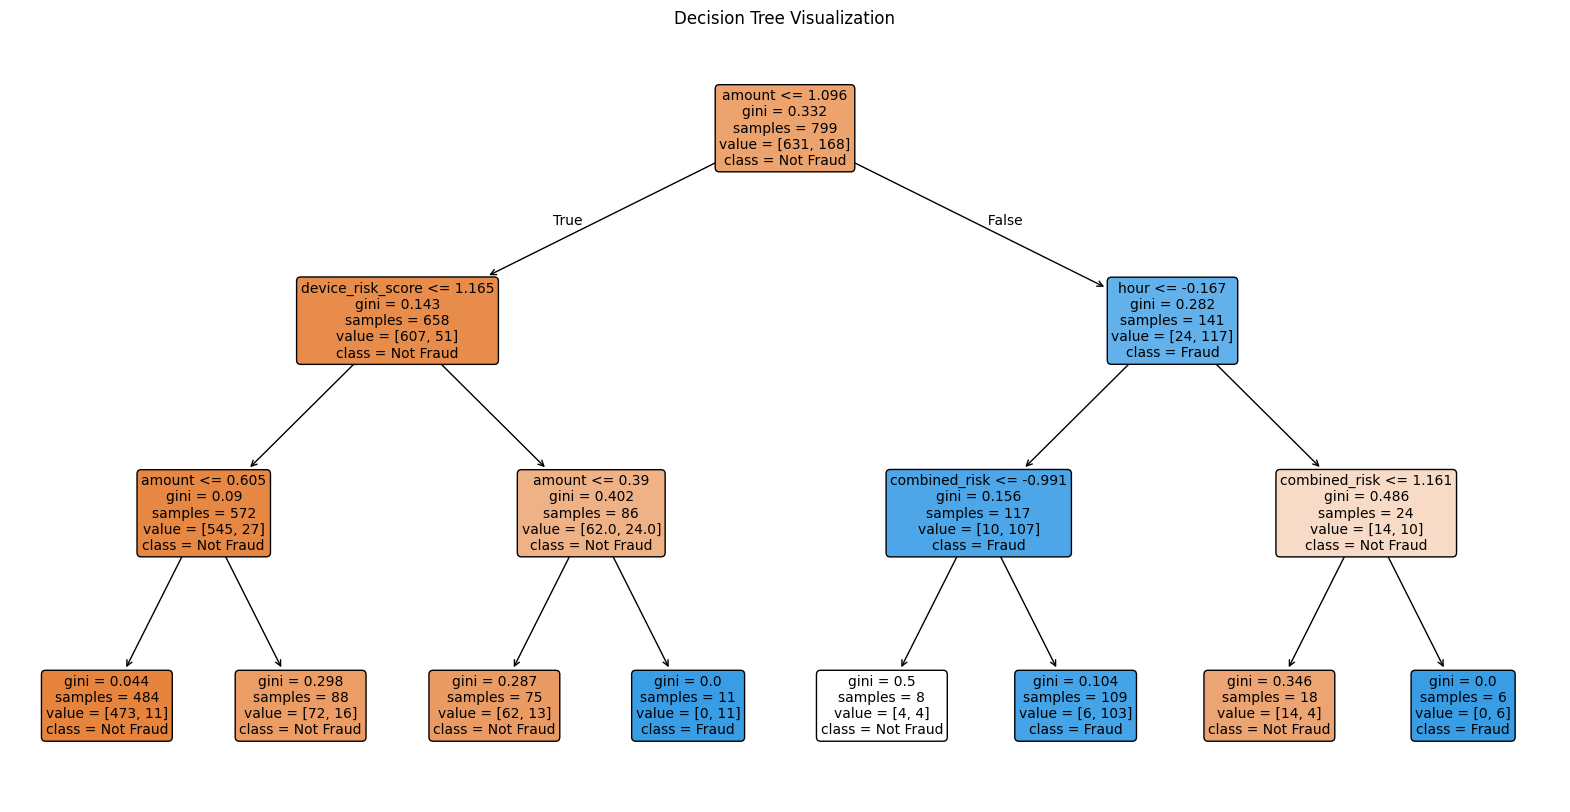

In [10]:
# Cell 7

from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Build a separate pipeline specifically for your single Decision Tree
dt_pipeline = Pipeline([
    ('risk_adder', RiskFeatureAdder()),
    ('preprocessor', preprocessor), # Converts strings to numbers inside the cross-validation slice
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42))
])

# 2. Train the pipeline on raw data
dt_pipeline.fit(X_train, y_train)

# 3. Pull out the engineered feature names for your chart labels
transformed_features = cat_cols + ['amount', 'hour', 'device_risk_score', 'ip_risk_score', 'combined_risk']

# 4. Visualization
plt.figure(figsize=(20, 10), dpi=100)
plot_tree(dt_pipeline.named_steps['classifier'], # Pulls the trained tree out of the pipeline
          feature_names=transformed_features,
          class_names=['Not Fraud', 'Fraud'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

**Random forest**

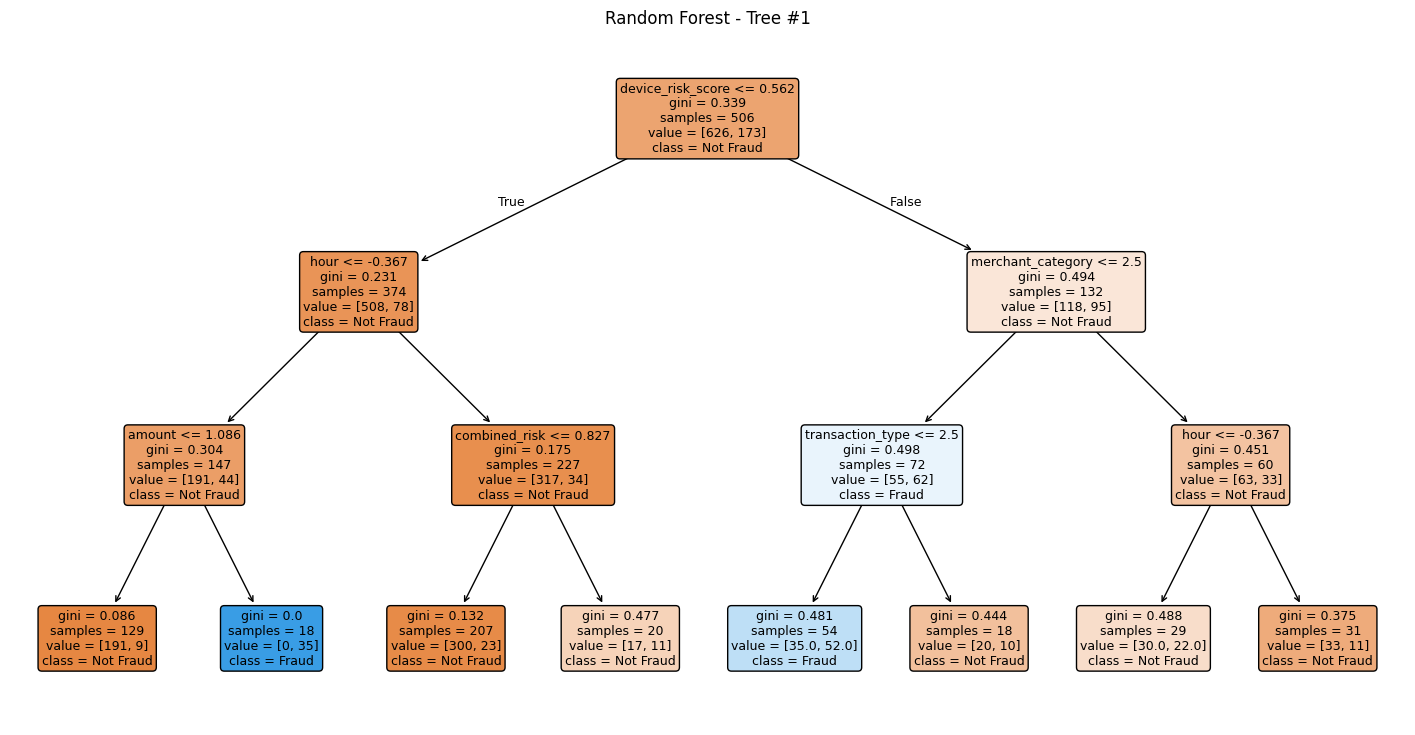

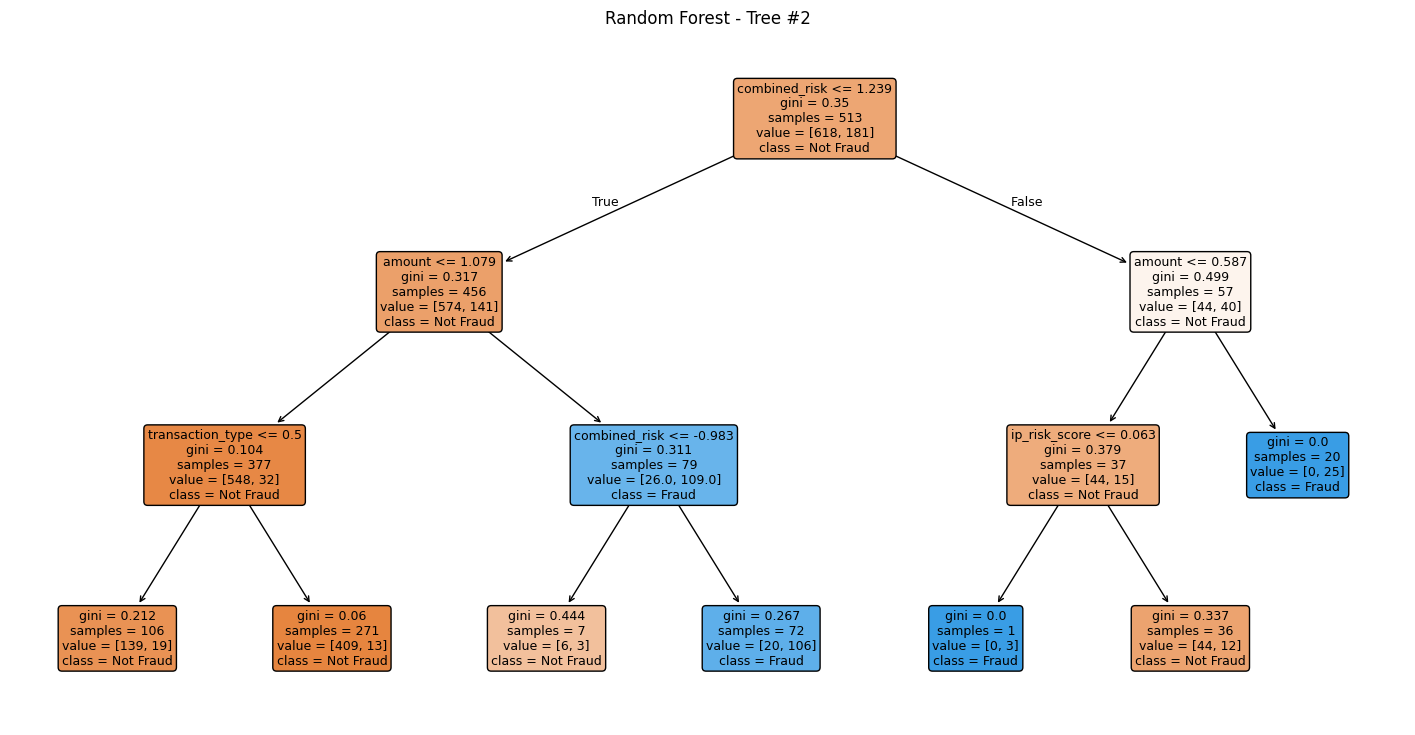

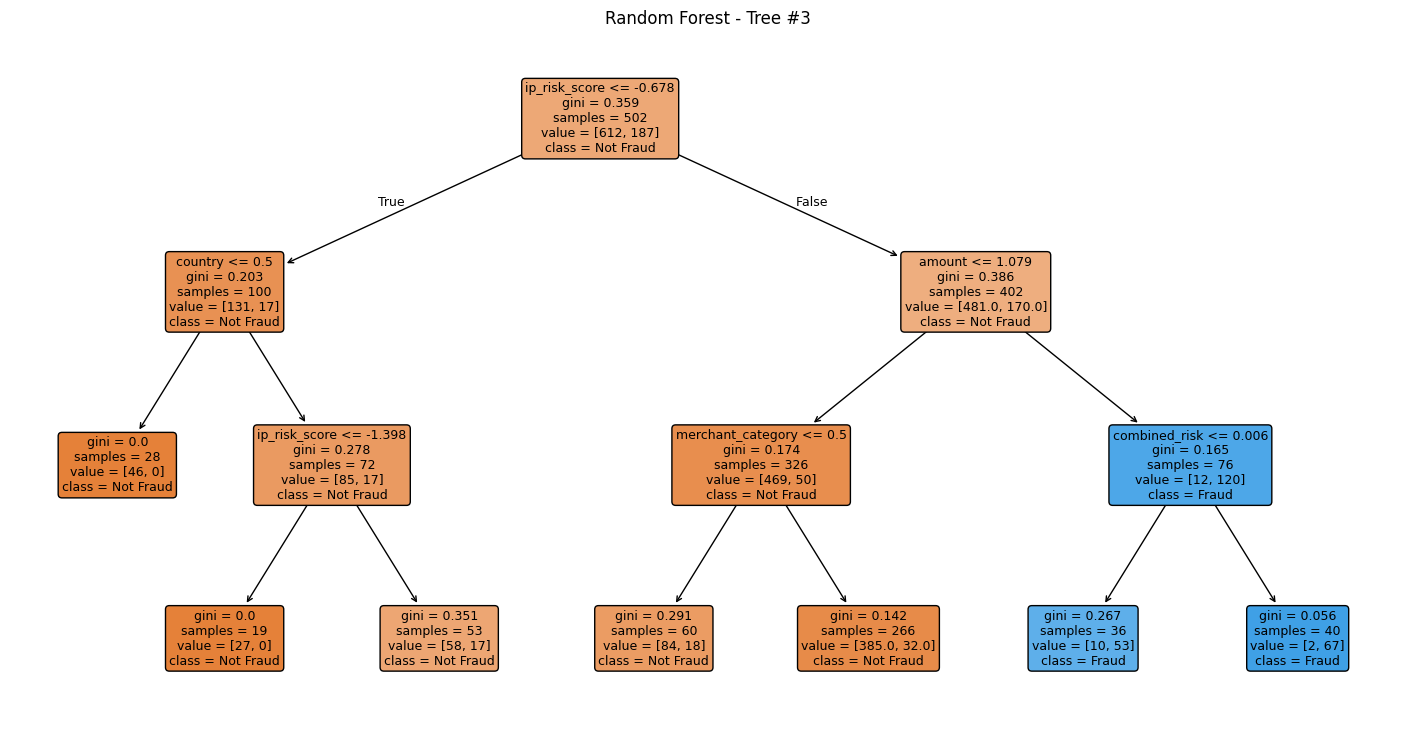

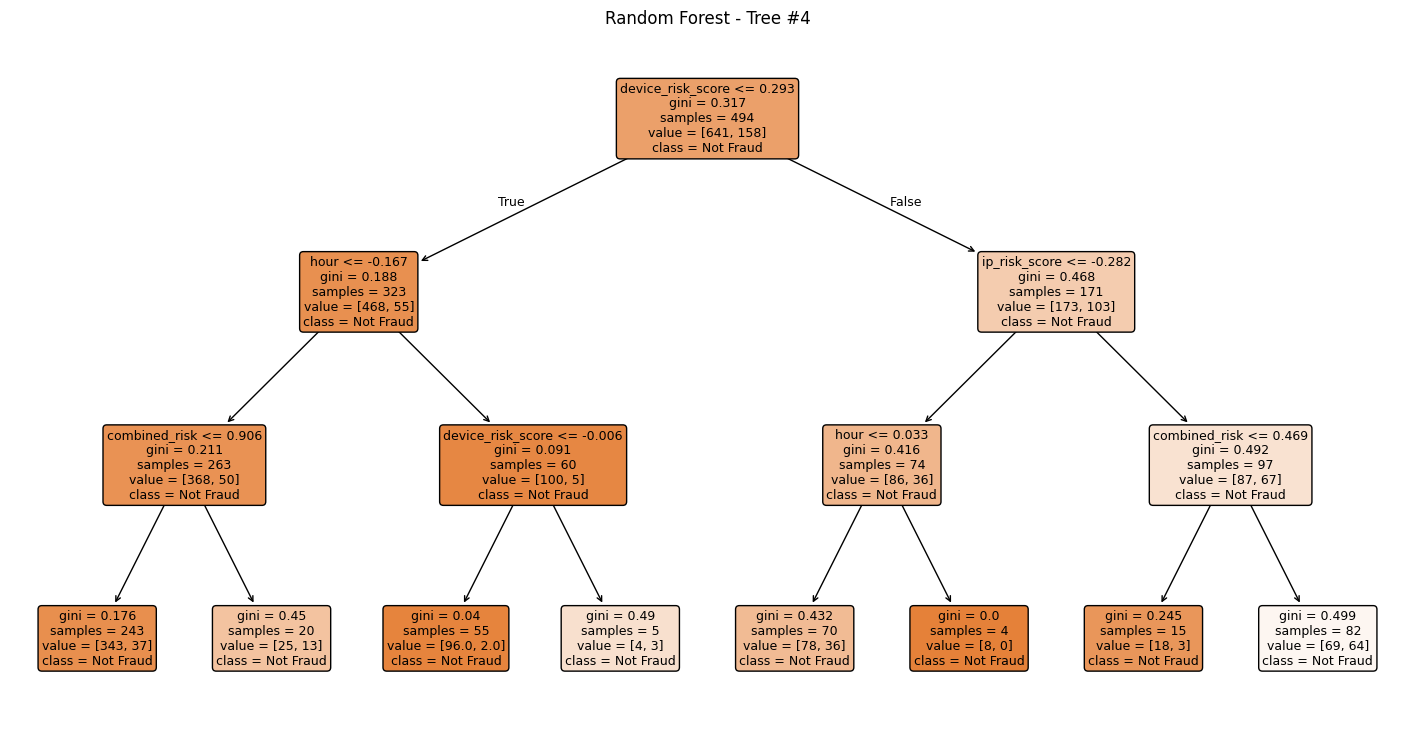

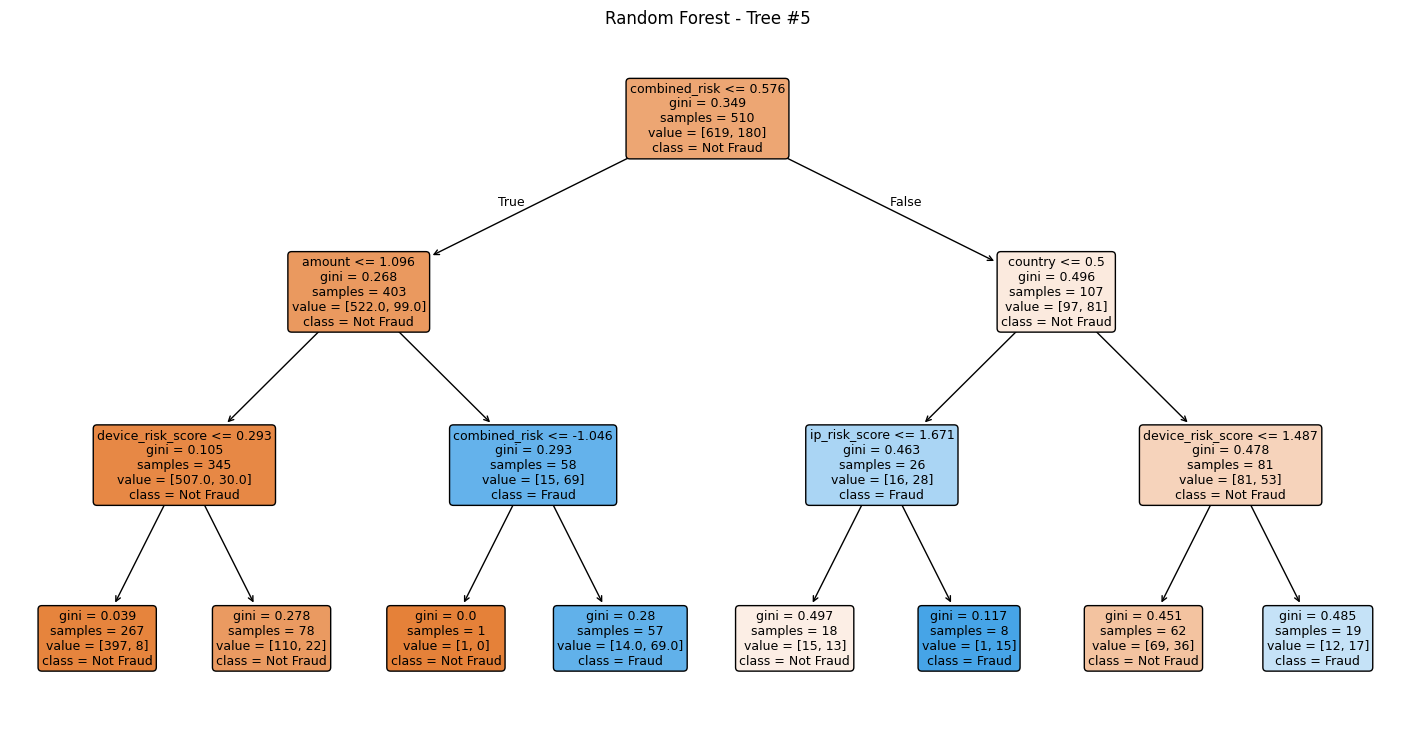

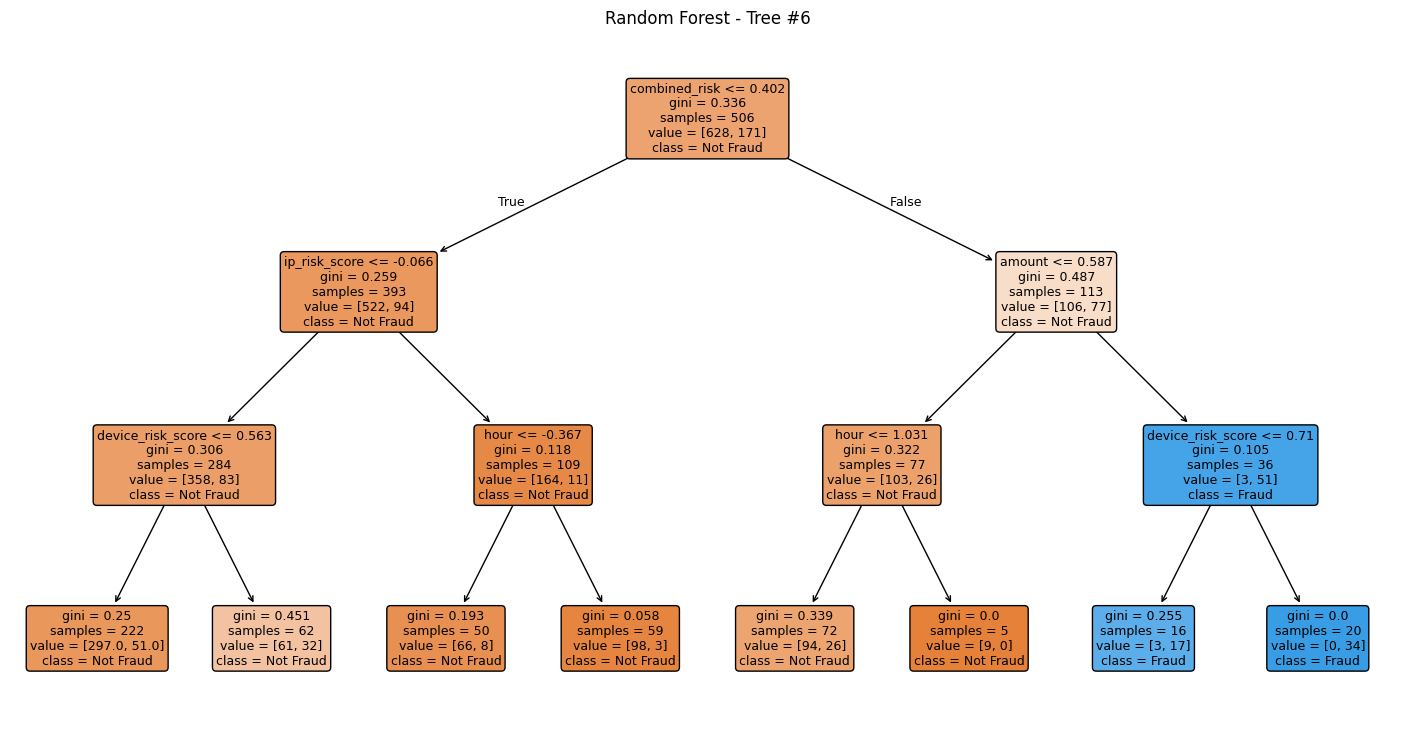

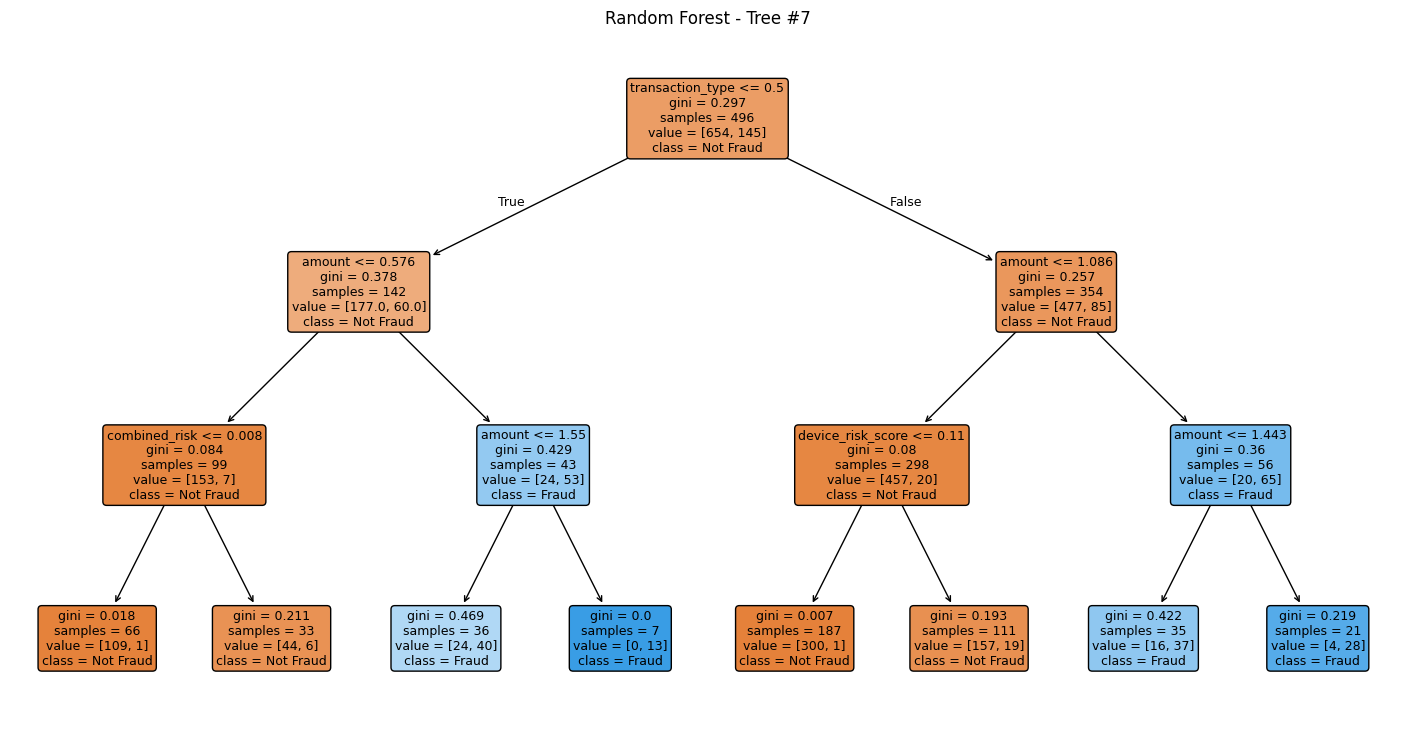

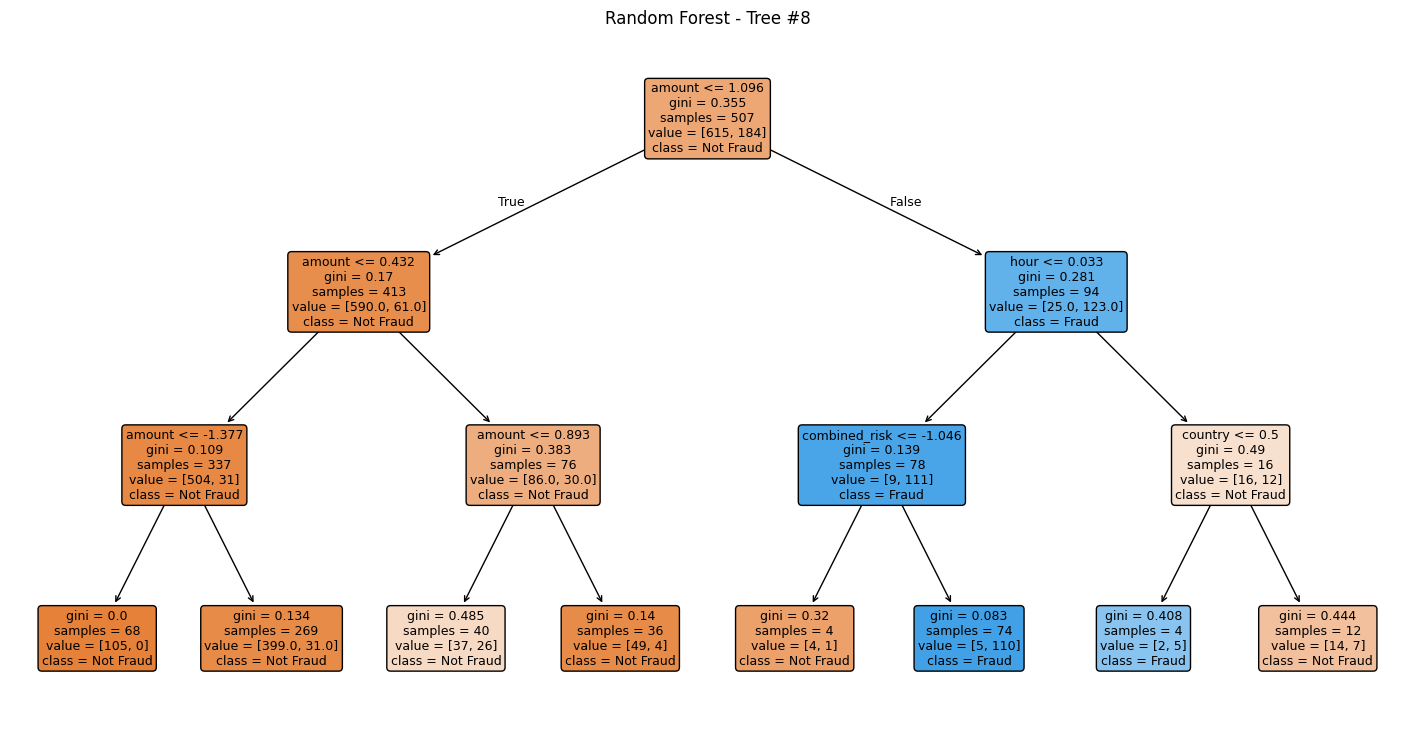

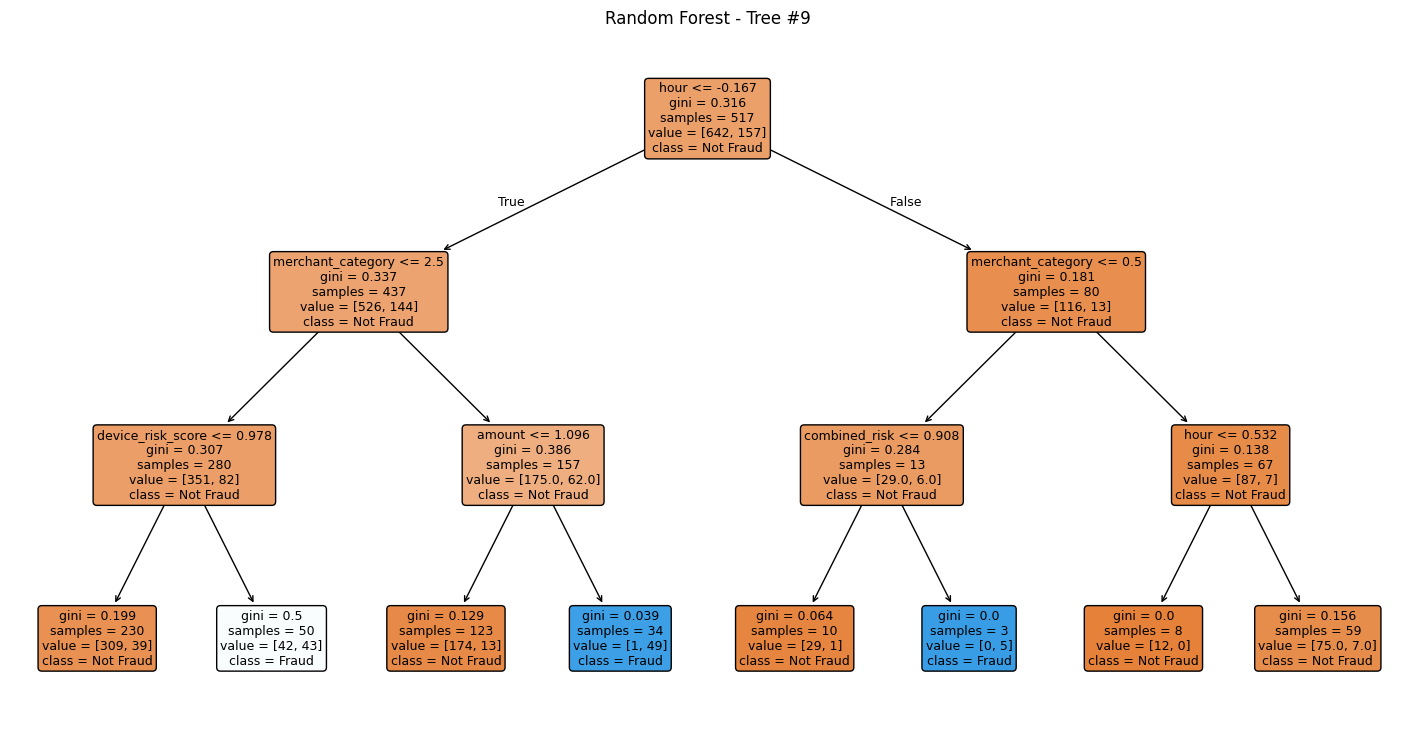

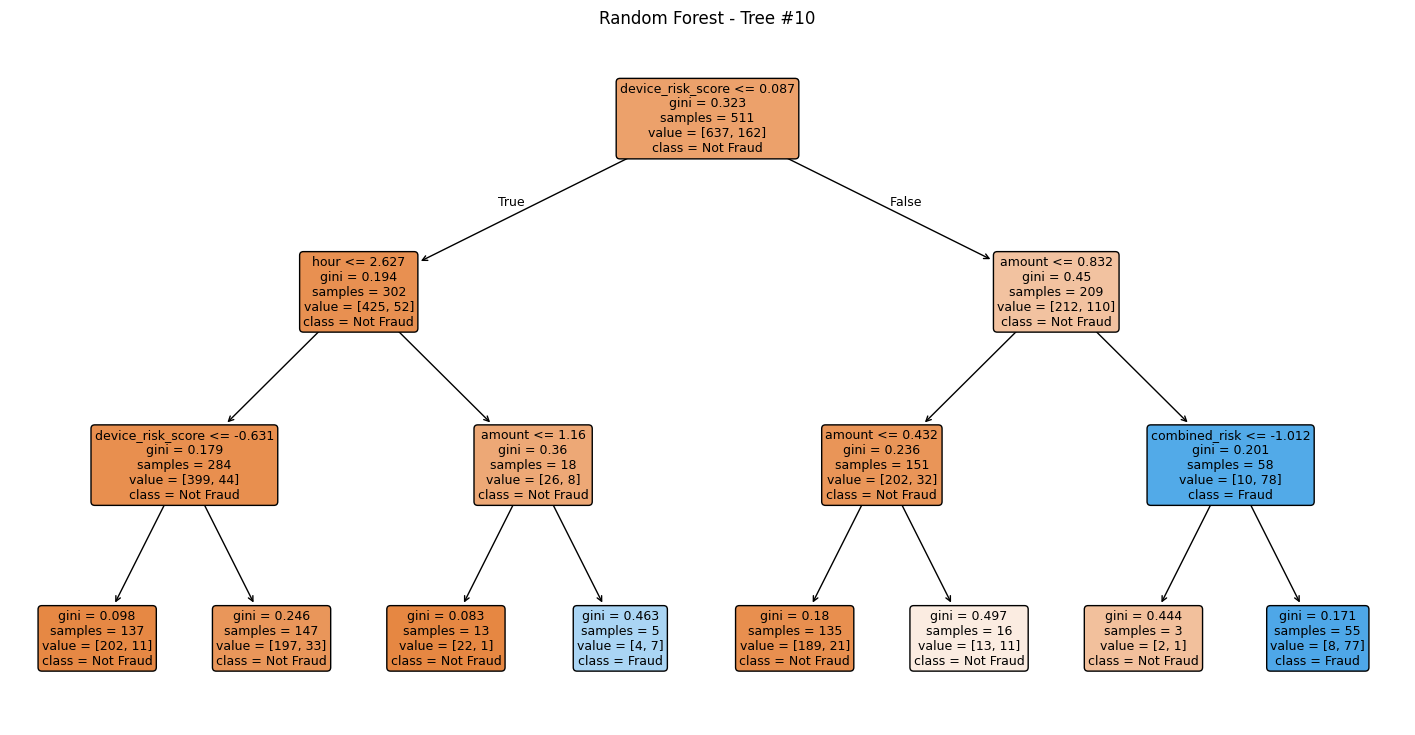

In [11]:
# Cell 8

# 1. Create the specific Random Forest for visualization (10 trees, shallow depth)
rf_viz = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)

# 2. Build a dedicated visualization pipeline to process the strings safely
rf_pipeline = Pipeline([
    ('risk_adder', RiskFeatureAdder()),
    ('preprocessor', preprocessor),
    ('classifier', rf_viz)
])

# 3. Train the pipeline using your raw training data
rf_pipeline.fit(X_train, y_train)

# 4. Extract aligned feature names for your chart labels
transformed_features = cat_cols + ['amount', 'hour', 'device_risk_score', 'ip_risk_score', 'combined_risk']
trained_rf = rf_pipeline.named_steps['classifier']

# 5. Run your loop to see the trees
for i in range(10):
    plt.figure(figsize=(18, 9), dpi=100)
    plot_tree(trained_rf.estimators_[i],
              feature_names=transformed_features,
              class_names=['Not Fraud', 'Fraud'],
              filled=True,
              rounded=True,
              fontsize=9)
    plt.title(f"Random Forest - Tree #{i+1}")
    plt.show()

# 6. Generate predictions using the visualization pipeline for the charts below
y_pred = rf_pipeline.predict(X_test)
probs = rf_pipeline.predict_proba(X_test)[:, 1]

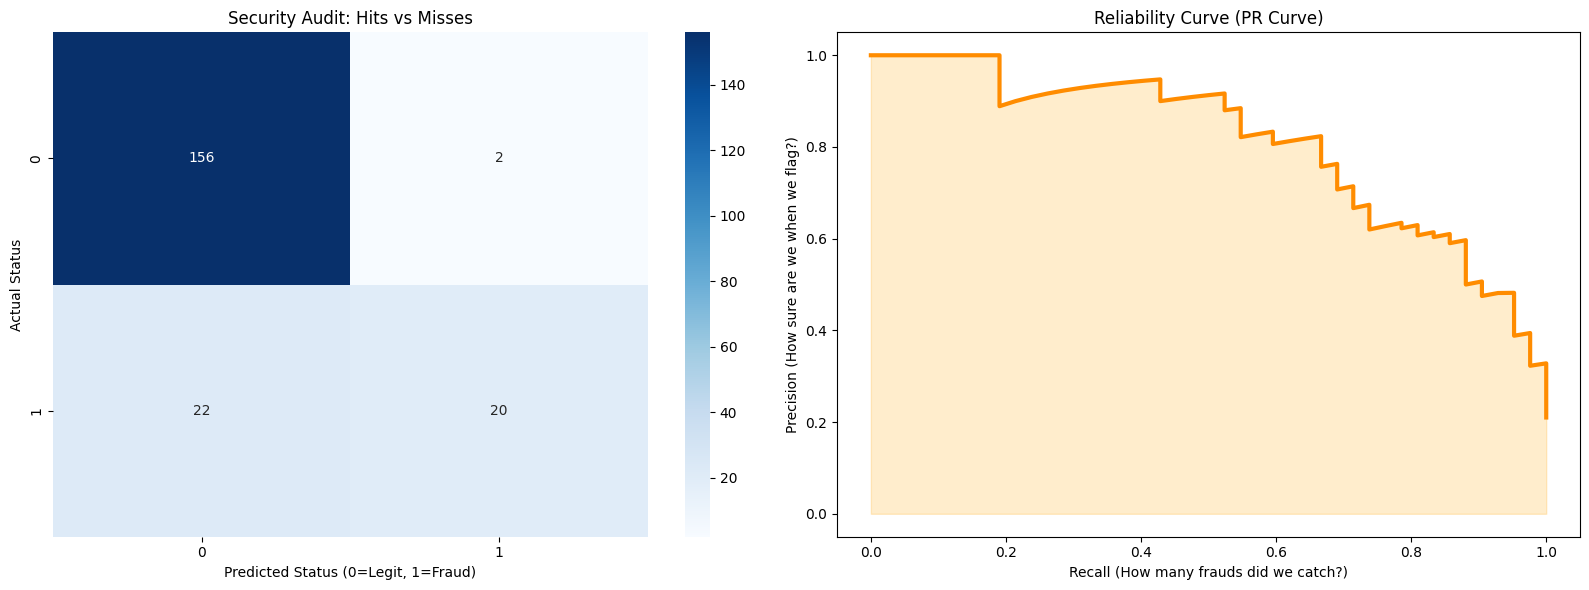

In [12]:
# Cell 9

from sklearn.metrics import confusion_matrix, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Security Audit: Hits vs Misses')
ax[0].set_xlabel('Predicted Status (0=Legit, 1=Fraud)')
ax[0].set_ylabel('Actual Status')

precision, recall, _ = precision_recall_curve(y_test, probs)
ax[1].plot(recall, precision, color='darkorange', lw=3)
ax[1].fill_between(recall, precision, alpha=0.2, color='orange')
ax[1].set_title('Reliability Curve (PR Curve)')
ax[1].set_xlabel('Recall (How many frauds did we catch?)')
ax[1].set_ylabel('Precision (How sure are we when we flag?)')

plt.tight_layout()
plt.show()

In [13]:
# Cell 9

# The correct way to predict using your trained pipeline wrapper:
y_pred = rf_pipeline.predict(X_test)
probs = rf_pipeline.predict_proba(X_test)[:, 1]

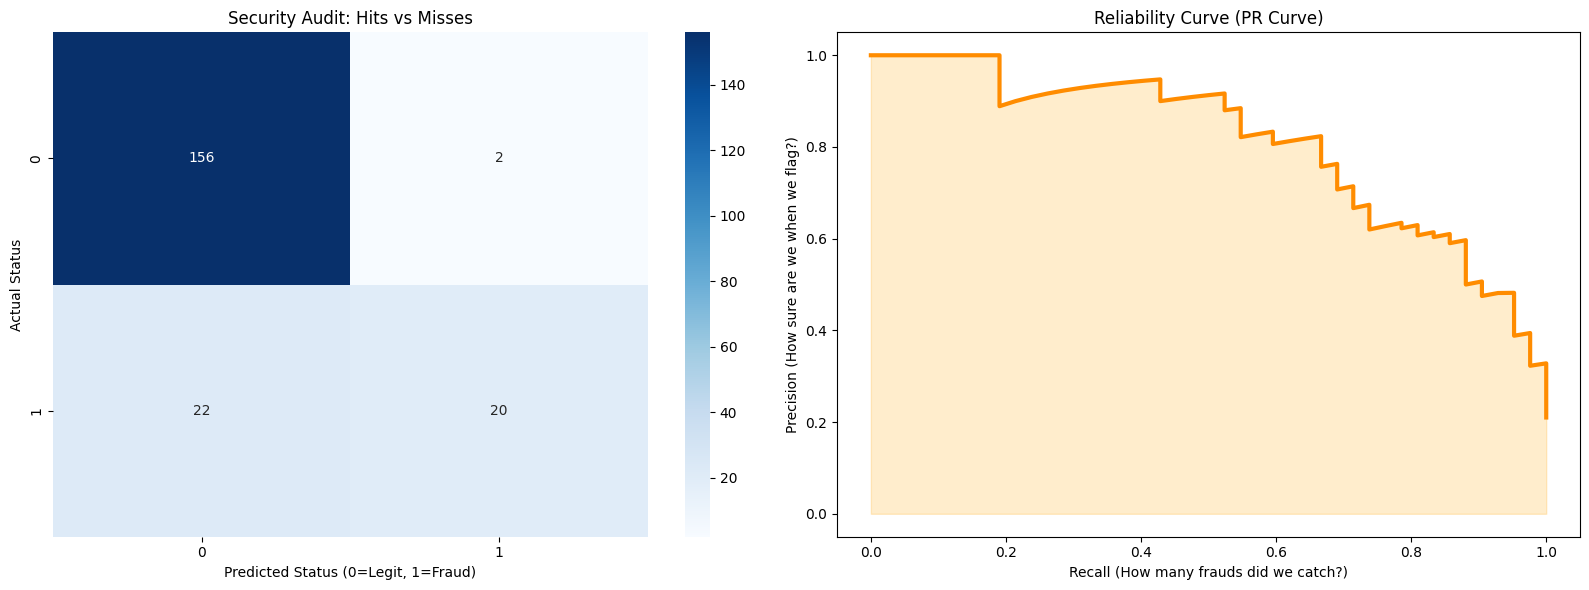

In [14]:
# Cell 10

from sklearn.metrics import confusion_matrix, precision_recall_curve

# 1. Create the 'Frame' (The empty layout)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 2. Put the first picture in the LEFT slot (ax[0])
# confusion_matrix compares your model's guesses (y_pred) against the truth (y_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Security Audit: Hits vs Misses')
ax[0].set_xlabel('Predicted Status (0=Legit, 1=Fraud)')
ax[0].set_ylabel('Actual Status')

# 3. Put the second picture in the RIGHT slot (ax[1])
# precision_recall_curve uses the probabilities (probs) to see how the model behaves at different thresholds
precision, recall, _ = precision_recall_curve(y_test, probs)
ax[1].plot(recall, precision, color='darkorange', lw=3)
ax[1].fill_between(recall, precision, alpha=0.2, color='orange')
ax[1].set_title('Reliability Curve (PR Curve)')
ax[1].set_xlabel('Recall (How many frauds did we catch?)')
ax[1].set_ylabel('Precision (How sure are we when we flag?)')

plt.tight_layout()
plt.show()

#**Overfitting Check**

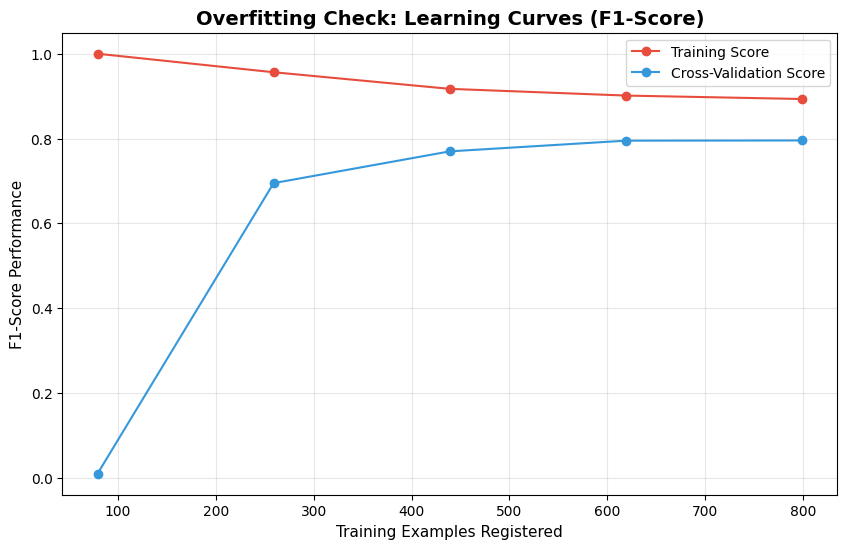

In [15]:
# Cell 11

import numpy as np
from sklearn.model_selection import learning_curve

# 1. Pass the fully unified pipeline and switch scoring to 'f1' for true imbalance tracking
train_sizes, train_scores, test_scores = learning_curve(
    fraud_model_pipeline,  # Use the pipeline wrapper to process strings safely
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color='#3498db', label="Cross-Validation Score")

plt.title("Overfitting Check: Learning Curves (F1-Score)", fontsize=14, fontweight='bold')
plt.xlabel("Training Examples Registered", fontsize=11)
plt.ylabel("F1-Score Performance", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.show()

#**Measuring Importance Score**
An Importance Score (often called Feature Importance) is a numerical value that represents how much a specific piece of data contributed to the model's decision-making process.

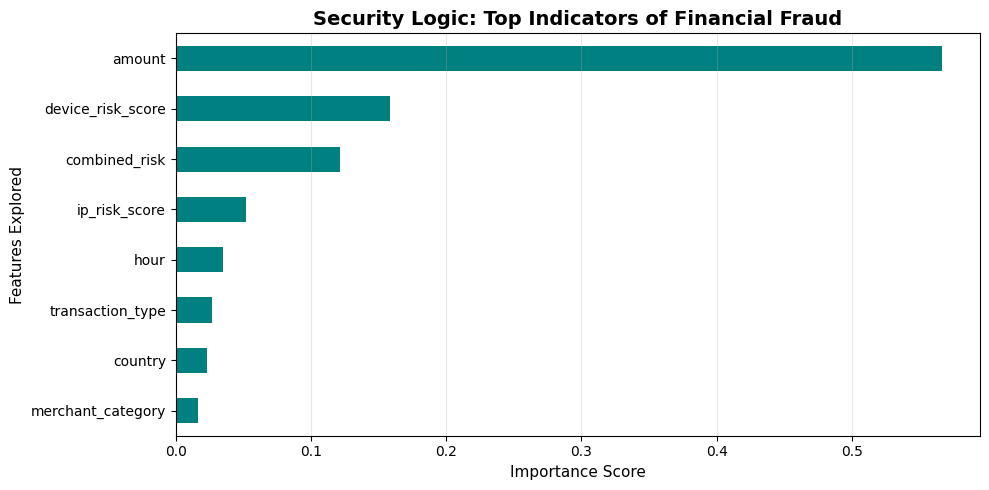

In [16]:
# Cell 12

# 1. Extract the actual trained Random Forest from your main pipeline wrapper
trained_rf = fraud_model_pipeline.named_steps['classifier']

# 2. Reconstruct the features in the exact order the transformer processed them
transformed_features = cat_cols + ['amount', 'hour', 'device_risk_score', 'ip_risk_score', 'combined_risk']

# 3. Pair the importances with the correct feature names safely
importances = pd.Series(trained_rf.feature_importances_, index=transformed_features).sort_values()

# 4. Plot Chart
plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='teal')
plt.title('Security Logic: Top Indicators of Financial Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Features Explored', fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#**Anomaly Detection Model (Classification Report)**

In [17]:
# Cell 13

from sklearn.metrics import classification_report

# Now this will work!
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       158
           1       0.91      0.48      0.62        42

    accuracy                           0.88       200
   macro avg       0.89      0.73      0.78       200
weighted avg       0.88      0.88      0.86       200



#**Advanced Risk Separation & Matrix Visuals**

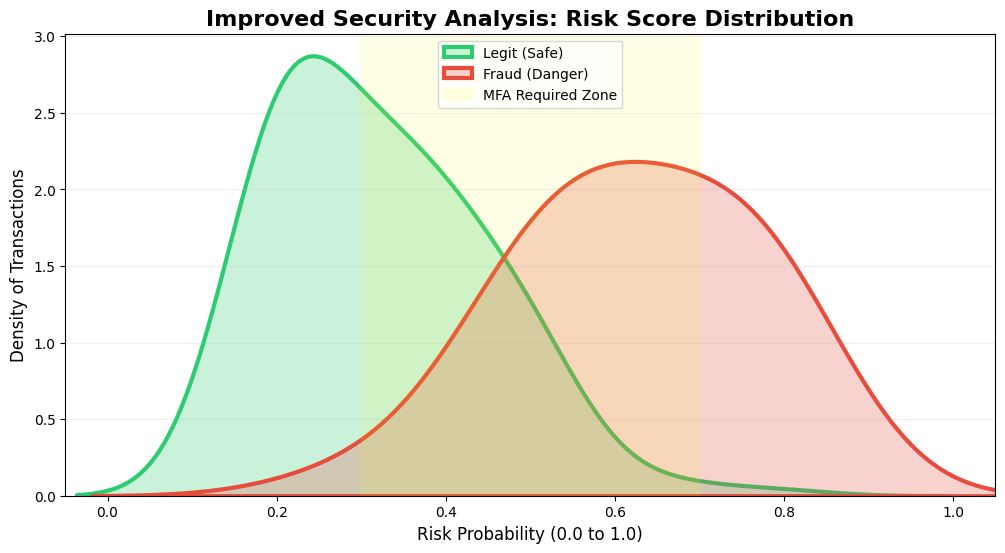

In [18]:
# Cell 14

# 1. Define your specific 'Soft' classifier parameters
soft_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

# 2. Re-wrap it with your leak-free pipeline steps to safely process strings
soft_rf_pipeline = Pipeline([
    ('risk_adder', RiskFeatureAdder()),
    ('preprocessor', preprocessor),
    ('classifier', soft_classifier)
])

soft_rf_pipeline.fit(X_train, y_train)
soft_probs = soft_rf_pipeline.predict_proba(X_test)[:, 1]

# --- 3. PLOT RISK DISTRIBUTION ---
plt.figure(figsize=(12, 6))
sns.kdeplot(soft_probs[y_test == 0], fill=True, label="Legit (Safe)", color="#2ecc71", lw=3, bw_adjust=1.5)
sns.kdeplot(soft_probs[y_test == 1], fill=True, label="Fraud (Danger)", color="#e74c3c", lw=3, bw_adjust=1.5)
plt.axvspan(0.3, 0.7, alpha=0.1, color='yellow', label='MFA Required Zone')
plt.title('Improved Security Analysis: Risk Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Risk Probability (0.0 to 1.0)', fontsize=12)
plt.ylabel('Density of Transactions', fontsize=12)
plt.xlim(-0.05, 1.05)
plt.legend(loc='upper center')
plt.grid(axis='y', alpha=0.2)
plt.show()

#**The "Fraud Recovery" Heatmap**

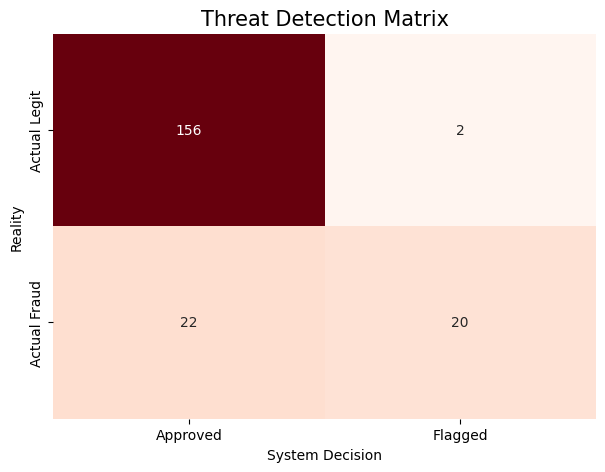

In [19]:
# Cell 15

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Approved', 'Flagged'],
            yticklabels=['Actual Legit', 'Actual Fraud'])

plt.title('Threat Detection Matrix', fontsize=15)
plt.ylabel('Reality')
plt.xlabel('System Decision')
plt.show()

#**The "System Reliability" (Precision-Recall)**

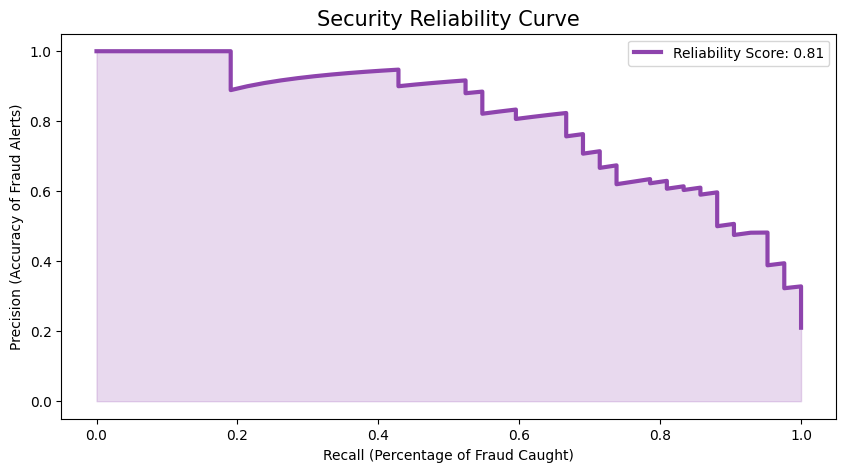

In [20]:
# Cell 16

from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 5))
plt.plot(recall, precision, color='#8e44ad', lw=3, label=f'Reliability Score: {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.2, color='#8e44ad')

plt.title('Security Reliability Curve', fontsize=15)
plt.xlabel('Recall (Percentage of Fraud Caught)')
plt.ylabel('Precision (Accuracy of Fraud Alerts)')
plt.legend()
plt.show()

#**Model Evaluation**

ROC-AUC: 0.927


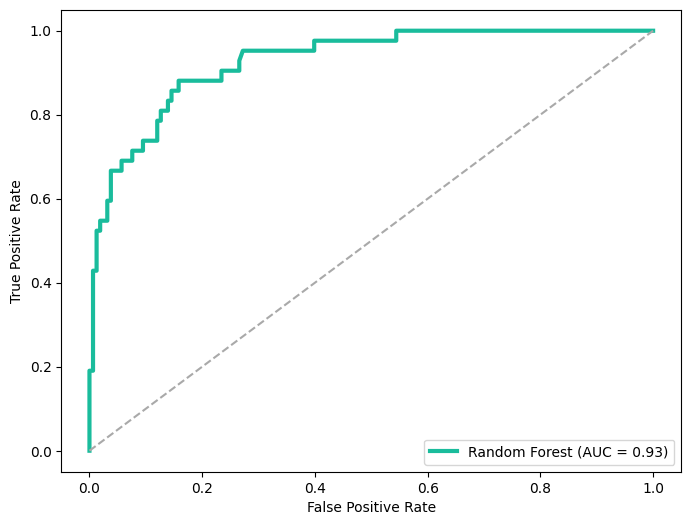

In [21]:
# Cell 17

from sklearn.metrics import roc_auc_score, roc_curve

# Use the primary trained pipeline to get probabilities safely
probs = rf_pipeline.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, probs)
print(f"ROC-AUC: {auc_score:.3f}")

fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1abc9c', lw=3, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='darkgray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

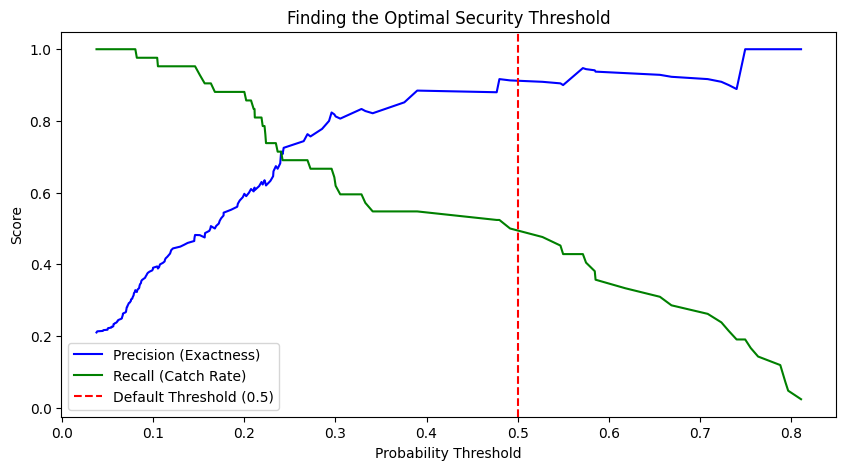

In [22]:
# Cell 18

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label="Precision (Exactness)", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall (Catch Rate)", color="green")
plt.axvline(x=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.title('Finding the Optimal Security Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

#**Transformer (LLM)**

In [23]:
# Cell 19

from transformers import pipeline

# 1. INITIALIZE TRANSFORMER (Place this above your widgets)
# We use a 'zero-shot-classification' model.
# This is the 'best' for your project because it can categorize
# transactions without extra training.
security_analyzer = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# 2. CREATE A HELPER FUNCTION
def analyze_transaction_memo(text):
    candidate_labels = ["fraudulent intent", "legitimate purchase", "suspicious activity"]
    result = security_analyzer(text, candidate_labels)
    # Returns the top suspected category
    return result['labels'][0], result['scores'][0]

# --- NOW YOUR INTERACTIVE TESTING CODE STARTS BELOW ---

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

#**Interactive Live Inference UI Function & Elementsn**
Uses LLM to read the transaction memo to see if the language sounds "suspicious" or "fraudulent."

In [24]:
# Cell 20

import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. THE INFERENCE SIMULATOR FUNCTION
def simulate_transaction(amount, hour, device_risk, ip_risk, tx_type, merchant, country):
    input_data = pd.DataFrame([{
        'amount': amount,
        'hour': hour,
        'device_risk_score': device_risk,
        'ip_risk_score': ip_risk,
        'transaction_type': tx_type,
        'merchant_category': merchant,
        'country': country
    }])

    # Run prediction directly through our trained pipeline
    risk_prob = fraud_model_pipeline.predict_proba(input_data)[0][1]

    print(f"📊 ML ENGINE RISK SCORE: {risk_prob:.2%}")
    if risk_prob > 0.70:
        print("❌ STATUS: TRANSACTION DECLINED (High Risk)")
    elif risk_prob > 0.35:
        print("⚠️ STATUS: STEP-UP AUTHENTICATION (MFA Required)")
    else:
        print("✅ STATUS: TRANSACTION APPROVED")

# 2. SETUP CONTROLS FOR LIVE USER INPUT
amount_in = widgets.FloatText(value=120.0, description='Amount ($):')
hour_in = widgets.IntSlider(value=14, min=0, max=23, description='Hour (0-23):')
dev_in = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='Device Risk:')
ip_in = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='IP Risk:')

# Dropdowns pass raw text matching data schema fields
type_in = widgets.Dropdown(options=['Online', 'In-Store', 'POS'], value='Online', description='Tx Type:')
merchant_in = widgets.Dropdown(options=['Retail', 'Entertainment', 'Electronics', 'Gas Station'], value='Retail', description='Merchant:')
country_in = widgets.Dropdown(options=['US', 'CA', 'UK', 'FR'], value='US', description='Country:')

memo_in = widgets.Textarea(value='', placeholder='Type transaction memo here...', description='Memo:')
btn = widgets.Button(description="Verify Transaction", button_style='primary')
output = widgets.Output()

# 3. INTERACTIVE CLICK HANDLER
def on_click(b):
    with output:
        clear_output()

        u_amt = amount_in.value
        u_hr = hour_in.value
        u_dev = dev_in.value
        u_ip = ip_in.value
        u_type = type_in.value
        u_merchant = merchant_in.value
        u_country = country_in.value
        u_memo = memo_in.value

        # A. Numerical Machine Learning Execution
        print("🤖 MACHINE LEARNING RISK ENGINE")
        simulate_transaction(u_amt, u_hr, u_dev, u_ip, u_type, u_merchant, u_country)

        # B. Linguistic Transformer Execution
        if u_memo.strip():
            print("\n" + "."*40)
            print("🔍 AI LINGUISTIC ANALYSIS (Transformer)")
            label, score = analyze_transaction_memo(u_memo)
            print(f"Detected Intent: {label.upper()}")
            print(f"AI Confidence: {score:.2%}")
            print("."*40)

        # Rule Override
        if u_amt > 10000 and (u_hr > 22 or u_hr < 5):
            print("\n❗ SYSTEM ALARM: High-value nocturnal activity detected.")

btn.on_click(on_click)

print("🛡️ SECURE-GATE: MULTI-MODAL RISK ASSESSMENT")
display(amount_in, hour_in, dev_in, ip_in, type_in, merchant_in, country_in, memo_in, btn, output)

🛡️ SECURE-GATE: MULTI-MODAL RISK ASSESSMENT


FloatText(value=120.0, description='Amount ($):')

IntSlider(value=14, description='Hour (0-23):', max=23)

FloatSlider(value=0.1, description='Device Risk:', max=1.0, step=0.01)

FloatSlider(value=0.1, description='IP Risk:', max=1.0, step=0.01)

...

Dropdown(description='Merchant:', options=('Retail', 'Entertainment', 'Electronics', 'Gas Station'), value='Re…

Dropdown(description='Country:', options=('US', 'CA', 'UK', 'FR'), value='US')

Textarea(value='', description='Memo:', placeholder='Type transaction memo here...')

Button(button_style='primary', description='Verify Transaction', style=ButtonStyle())

Output()